# Introduction

In [206]:
import os
from pathlib import Path
import torch, numpy as np, pandas as pd

In [207]:
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

# Cleaning the data

In [208]:
df = pd.read_csv('train.csv')

In [209]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [210]:
df.isna().sum() # Find the number of NaN/empty values in all the columns

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [211]:
modes = df.mode().iloc[0] # Find the most common value in all the respective columns
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [212]:
df.fillna(modes, inplace=True) # Replace the empty values with their respective column's mode

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [213]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [214]:
df.describe(include=(np.number))

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


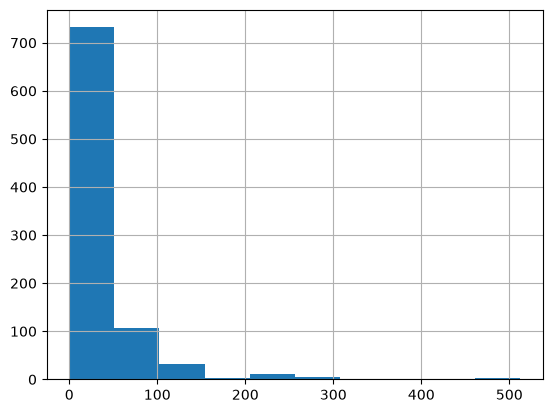

In [215]:
df['Fare'].hist();

In [216]:
df['LogFare'] = np.log(df['Fare']+1) # Take the log of the 'Fare' column to get rid of the 'Long Tail Distribution'. We add 1 because some fares are zero.

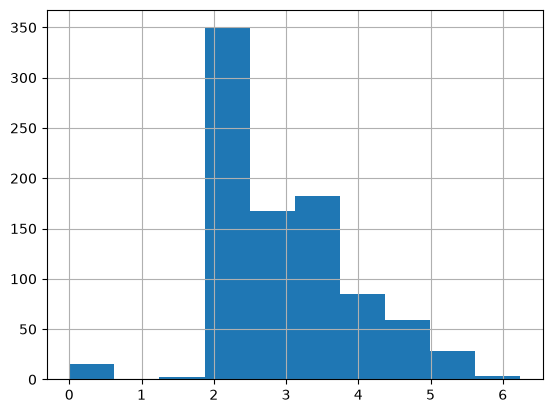

In [217]:
df['LogFare'].hist();

In [218]:
pclasses = sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

In [219]:
df.describe(include=[str])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,691,646


In [220]:
df = pd.get_dummies(df, columns=["Pclass", "Sex", "Embarked"]) # Get a separate boolean column for each unique value of the provided columns. This is usually done for categorical data.

In [221]:
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Pclass_1', 'Pclass_2',
       'Pclass_3', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [222]:
added_columns = ['Sex_male', 'Sex_female', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
df[added_columns]

,Sex_male,Sex_female,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,True,False,False,False,True,False,False,True
1,False,True,True,False,False,True,False,False
2,False,True,False,False,True,False,False,True
3,False,True,True,False,False,False,False,True
4,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...
886,True,False,False,True,False,False,False,True
887,False,True,True,False,False,False,False,True
888,False,True,False,False,True,False,False,True
889,True,False,True,False,False,True,False,False


In [223]:
df[added_columns] = df[added_columns].astype(float)

In [224]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [225]:
from torch import tensor
# Tensor is just an array
t_dep = tensor(df.Survived).to(device)

In [226]:
t_dep.shape

torch.Size([891])

In [227]:
t_dep.device

device(type='cuda', index=0)

In [228]:
indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare'] + added_columns

t_indep = tensor(df[indep_cols].values, dtype=torch.float).to(device)
t_indep

tensor([[22.0000,  1.0000,  0.0000,  2.1102,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000,  4.2806,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  2.1889,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000,  3.9908,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  0.0000,  0.0000,  2.2028,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [24.0000,  0.0000,  0.0000,  2.2469,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [54.0000,  0.0000,  0.0000,  3.9677,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  2.0857,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [39.0000,  0.0000,  5.0000,  3.4054

In [229]:
t_indep.shape

torch.Size([891, 12])

In [230]:
len(t_indep.shape) # This is called the rank of the tensor

2

# Setting up a linear model

In [231]:
torch.manual_seed(442)

n_coeff = t_indep.shape[1]
coeffs = (torch.rand(n_coeff)-0.5).to(device)
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], device='cuda:0')

In [232]:
t_indep.device

device(type='cuda', index=0)

In [233]:
coeffs.device

device(type='cuda', index=0)

In [234]:
result = t_indep*coeffs # Multiplying a matrix with a vector using broadcasting
result

tensor([[-10.1838,   0.1386,   0.0000,  -0.4772,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  -0.9681,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  -0.4950,  -0.0000,  -0.3147,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.1386,   0.0000,  -0.9025,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.0000,   0.0000,  -0.4982,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-11.1096,   0.0000,   0.0000,  -0.5081,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.2103,   0.0000],
        [-24.9966,   0.0000,   0.0000,  -0.8973,  -0.2632,  -0.0000,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.5725,   0.0000,   0.0000,  -0.4717,  -0.2632,  -0.0000,   0.0000

In [235]:
result.device

device(type='cuda', index=0)

In [236]:
vals, indices = t_indep.max(dim=0) # Taking the maximum for normalizing
t_indep = t_indep / vals # Dividing a matrix by a vector using broadcasting

In [237]:
vals.device

device(type='cuda', index=0)

In [238]:
result = t_indep*coeffs
result

tensor([[-0.1273,  0.0173,  0.0000, -0.0765, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000, -0.1551, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000, -0.0793, -0.0000, -0.3147,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0173,  0.0000, -0.1446, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0000,  0.0000, -0.0798, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.1389,  0.0000,  0.0000, -0.0814, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.2103,  0.0000],
        [-0.3125,  0.0000,  0.0000, -0.1438, -0.2632, -0.0000,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1447,  0.0000,  0.0000, -0.0756, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2257,  0.0000,  0.2008, -0.1234

In [239]:
preds = result.sum(axis=1)

In [240]:
preds[:10]

tensor([ 0.1927, -0.6239,  0.0979,  0.2056,  0.0968,  0.0066,  0.1306,  0.3476,  0.1613, -0.6285], device='cuda:0')

In [241]:
preds.shape

torch.Size([891])

In [242]:
preds.device

device(type='cuda', index=0)

In [243]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.5382, device='cuda:0')

In [244]:
def calc_preds(coeffs, indeps): return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(calc_preds(coeffs, indeps)-deps).mean()

# Doing a gradient descent step

In [245]:
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], device='cuda:0',
       requires_grad=True)

In [246]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.5382, device='cuda:0', grad_fn=<MeanBackward0>)

In [247]:
loss.backward()

In [248]:
coeffs.grad

tensor([-0.0106,  0.0129, -0.0041, -0.0484,  0.2099, -0.2132, -0.1212, -0.0247,  0.1425, -0.1886, -0.0191,  0.2043], device='cuda:0')

In [249]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.5197, device='cuda:0')


In [250]:
coeffs

tensor([-0.4618,  0.1373,  0.2413, -0.2213, -0.2842, -0.2934,  0.4997,  0.3160,  0.2656, -0.4203,  0.2122,  0.3421], device='cuda:0',
       requires_grad=True)

# Training the linear model

In [251]:
from fastai.data.transforms import RandomSplitter
trn_split, val_split = RandomSplitter(seed=42)(df)

In [252]:
trn_split

(#713) [np.int64(788),np.int64(525),np.int64(821),np.int64(253),np.int64(374),np.int64(98),np.int64(215),np.int64(313),np.int64(281),np.int64(305)...]

In [253]:
val_split

(#178) [np.int64(303),np.int64(778),np.int64(531),np.int64(385),np.int64(134),np.int64(476),np.int64(691),np.int64(443),np.int64(386),np.int64(128)...]

In [254]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]
len(trn_indep), len(val_indep)

(713, 178)

In [255]:
len(trn_dep), len(val_dep)

(713, 178)

In [256]:
trn_indep.device

device(type='cuda', index=0)

In [257]:
val_indep.device

device(type='cuda', index=0)

In [258]:
trn_dep.device

device(type='cuda', index=0)

In [259]:
val_dep.device

device(type='cuda', index=0)

In [260]:
def update_coeffs(coeffs, lr): coeffs.sub_(coeffs.grad*lr)

In [261]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

In [262]:
def init_coeffs(): return (torch.rand(n_coeff)-0.5).to(device).requires_grad_()

In [291]:
def train_model(epochs=30, lr=0.1):
    torch.manual_seed(442)
    coeffs=init_coeffs()
    for i in range(epochs): one_epoch(coeffs, lr)
    return coeffs

In [264]:
coeffs = train_model(18, lr=0.02)

0.536; 0.532; 0.525; 0.515; 0.503; 0.489; 0.477; 0.466; 0.449; 0.424; 0.396; 0.373; 0.354; 0.338; 0.321; 0.306; 0.297; 0.295; 

In [265]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2335, device='cuda:0'),
 'SibSp': tensor(0.1025, device='cuda:0'),
 'Parch': tensor(0.2530, device='cuda:0'),
 'LogFare': tensor(0.1073, device='cuda:0'),
 'Sex_male': tensor(-0.4166, device='cuda:0'),
 'Sex_female': tensor(0.3314, device='cuda:0'),
 'Pclass_1': tensor(0.8639, device='cuda:0'),
 'Pclass_2': tensor(0.4225, device='cuda:0'),
 'Pclass_3': tensor(0.2875, device='cuda:0'),
 'Embarked_C': tensor(0.1840, device='cuda:0'),
 'Embarked_Q': tensor(0.3267, device='cuda:0'),
 'Embarked_S': tensor(0.1158, device='cuda:0')}

# Measuring accuracy

In [266]:
preds = calc_preds(coeffs, val_indep)

In [267]:
results = val_dep.bool()==(preds>0.5)
results[:16]

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True,  True, False], device='cuda:0')

In [268]:
results.float().mean()

tensor(0.7921, device='cuda:0')

In [269]:
def acc(coeffs): return((val_dep.bool()==(calc_preds(coeffs, val_indep)>0.5)).float().mean())

In [270]:
acc(coeffs)

tensor(0.7921, device='cuda:0')

# Using sigmoid

In [271]:
preds[:28]

tensor([ 1.0550,  0.1648,  0.0210,  0.1432,  0.0940,  0.0883,  0.8792,  0.8332,  0.1986,  0.8419, -0.0691,  0.0877,  0.0729,  0.9130,
        -0.0780,  0.4887,  0.4303,  0.8954,  0.0644,  0.6831, -0.0458,  0.4566,  1.4014,  0.8986, -0.0359,  0.1958,  0.8296,  0.4391],
       device='cuda:0')

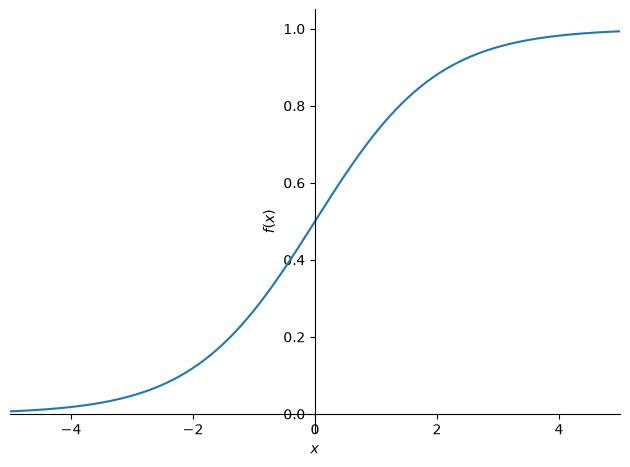

In [272]:
import sympy
from sympy import symbols

x = symbols('x')
expr = sympy.sympify("1/(1+exp(-x))")
sympy.plot(expr, xlim=(-5, 5));

In [273]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [274]:
coeffs = train_model(lr=2)

0.510; 0.468; 0.397; 0.340; 0.309; 0.289; 0.268; 0.247; 0.230; 0.218; 0.210; 0.207; 0.205; 0.204; 0.204; 0.204; 0.204; 0.205; 0.205; 0.205; 0.205; 0.205; 0.205; 0.204; 0.203; 0.202; 0.201; 0.200; 0.198; 0.197; 

In [275]:
acc(coeffs)

tensor(0.8258, device='cuda:0')

In [276]:
show_coeffs()

{'Age': tensor(-1.6562, device='cuda:0'),
 'SibSp': tensor(-1.1978, device='cuda:0'),
 'Parch': tensor(-0.0264, device='cuda:0'),
 'LogFare': tensor(2.0475, device='cuda:0'),
 'Sex_male': tensor(-18.9596, device='cuda:0'),
 'Sex_female': tensor(16.6258, device='cuda:0'),
 'Pclass_1': tensor(7.8170, device='cuda:0'),
 'Pclass_2': tensor(4.0900, device='cuda:0'),
 'Pclass_3': tensor(-12.5817, device='cuda:0'),
 'Embarked_C': tensor(3.1918, device='cuda:0'),
 'Embarked_Q': tensor(1.0449, device='cuda:0'),
 'Embarked_S': tensor(-5.8589, device='cuda:0')}

# Using matrix product

In [277]:
(val_indep*coeffs).sum(axis=1)

tensor([ 22.1141, -30.2821, -28.1549, -19.6869, -20.3803, -20.5681,   8.0241,  15.1430, -36.9090,   7.6186, -37.3447, -28.0859, -36.8184,
          5.3086, -37.4433, -16.8453, -17.2593,  15.4162, -20.4547,  -1.7118, -37.1801, -17.0730,  28.2207,  15.0791, -37.1301, -30.0850,
         -1.1708, -17.1972, -37.0081,   5.3037,  15.3412,  -1.6341, -37.0766, -37.3090,  21.9898,  -1.3241, -16.8080,  28.5329, -37.1745,
         -1.7640, -20.3206, -37.1745, -20.4117,  28.3984, -37.0917,  -1.4698, -36.6093, -37.0650, -30.3131,  -1.5780,  -9.8282, -37.0747,
        -37.0533, -37.2336, -20.4656, -20.5898, -30.2817, -37.3746, -37.1124, -37.0589,  -7.4700, -37.2175, -17.5311, -37.1169,  14.8775,
        -16.0102, -20.3596, -37.1497, -30.5589,  14.8026, -37.2215,   7.6448, -20.5691, -37.1257, -16.4181, -37.0190, -37.1745, -16.4581,
        -20.2561, -20.7920, -19.8429,  28.7201, -37.1594, -37.2048,  14.6230, -11.1232,  -6.9314,  19.7089,  24.2342, -20.3389, -37.3289,
        -37.1745,  28.5478, -28.27

In [278]:
val_indep@coeffs

tensor([ 22.1141, -30.2821, -28.1549, -19.6869, -20.3803, -20.5681,   8.0241,  15.1430, -36.9090,   7.6186, -37.3447, -28.0859, -36.8184,
          5.3086, -37.4433, -16.8453, -17.2593,  15.4162, -20.4547,  -1.7118, -37.1801, -17.0730,  28.2207,  15.0791, -37.1301, -30.0850,
         -1.1708, -17.1972, -37.0081,   5.3037,  15.3412,  -1.6341, -37.0766, -37.3090,  21.9898,  -1.3241, -16.8080,  28.5329, -37.1745,
         -1.7640, -20.3206, -37.1745, -20.4117,  28.3984, -37.0917,  -1.4698, -36.6093, -37.0650, -30.3131,  -1.5780,  -9.8282, -37.0747,
        -37.0533, -37.2336, -20.4656, -20.5898, -30.2817, -37.3746, -37.1124, -37.0589,  -7.4700, -37.2175, -17.5311, -37.1169,  14.8775,
        -16.0102, -20.3596, -37.1497, -30.5589,  14.8026, -37.2215,   7.6448, -20.5691, -37.1257, -16.4181, -37.0190, -37.1745, -16.4581,
        -20.2561, -20.7920, -19.8429,  28.7201, -37.1594, -37.2048,  14.6230, -11.1232,  -6.9314,  19.7089,  24.2342, -20.3389, -37.3290,
        -37.1745,  28.5478, -28.27

In [279]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps@coeffs)

In [280]:
def init_coeffs(): return (torch.rand(n_coeff, 1)*0.1).to(device).requires_grad_()

In [281]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]

In [282]:
trn_dep.shape

torch.Size([713, 1])

In [283]:
val_dep.shape

torch.Size([178, 1])

In [284]:
coeffs = train_model(lr=2)

0.512; 0.470; 0.394; 0.331; 0.299; 0.280; 0.263; 0.245; 0.229; 0.217; 0.210; 0.206; 0.204; 0.203; 0.203; 0.203; 0.203; 0.203; 0.203; 0.204; 0.203; 0.203; 0.203; 0.202; 0.201; 0.200; 0.199; 0.198; 0.197; 0.196; 

In [285]:
acc(coeffs)

tensor(0.8258, device='cuda:0')

In [286]:
coeffs

tensor([[ -1.6104],
        [ -1.2271],
        [ -0.1716],
        [  1.8728],
        [-19.4328],
        [ 16.9538],
        [  6.9896],
        [  3.7476],
        [-13.0004],
        [  2.6455],
        [  0.9067],
        [ -5.9101]], device='cuda:0', requires_grad=True)

# A neural network

In [287]:
def init_coeffs(n_hidden=20):
    layer_1 = (torch.rand(n_coeff, n_hidden)-0.5)/n_hidden
    layer_2 = torch.rand(n_hidden, 1)-0.3
    const = torch.rand(1)[0]
    return layer_1.to(device).requires_grad_(), layer_2.to(device).requires_grad_(), const.to(device).requires_grad_()

In [288]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    l1, l2, const = coeffs
    res = F.relu(indeps@l1)
    res = res@l2 + const
    return torch.sigmoid(res)

In [289]:
def update_coeffs(coeffs, lr):
    for layer in coeffs: layer.sub_(layer.grad * lr)

In [292]:
coeffs = train_model(lr=1.4)

0.543; 0.532; 0.509; 0.467; 0.396; 0.315; 0.271; 0.239; 0.213; 0.206; 0.208; 0.210; 0.211; 0.209; 0.203; 0.193; 0.192; 0.192; 0.192; 0.192; 0.192; 0.193; 0.194; 0.193; 0.191; 0.191; 0.192; 0.192; 0.192; 0.192; 

In [293]:
acc(coeffs)

tensor(0.8258, device='cuda:0')

# Deep Learning

In [302]:
def init_coeffs():
    hiddens = [10, 10] # Set this to size of each hidden layer you want. [10, 10] means 2 layers with 10 activation nodes in each.
    sizes = [n_coeff] + hiddens + [1] # In our example, this gives [12, 10, 10, 1]
    n = len(sizes) # In our example, this gives 4
    layers = [((torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4).to(device).requires_grad_() for i in range(n-1)]
    consts = [((torch.rand(1)[0]-0.5)*0.1).to(device).requires_grad_() for i in range(n-1)]
    return layers, consts

In [303]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers, consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [304]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers+consts: layer.sub_(layer.grad*lr)

In [305]:
coeffs = train_model(lr=1.4)

0.521; 0.462; 0.377; 0.370; 0.371; 0.350; 0.290; 0.196; 0.220; 0.223; 0.221; 0.218; 0.219; 0.218; 0.215; 0.214; 0.211; 0.201; 0.197; 0.199; 0.197; 0.194; 0.192; 0.192; 0.191; 0.191; 0.191; 0.190; 0.191; 0.192; 

In [306]:
acc(coeffs)

tensor(0.8258, device='cuda:0')